# Requirements

In [1]:
!python -m pip install pandas matplotlib mysql-connector-python


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# MySql Connection

In [1]:
import mysql.connector
import pandas as pd

connection = mysql.connector.connect(
    host="localhost", # 127.0.0.1:3036
    user="root",
    password="0221",
    database="train"
)

print("Database Connected")

Database Connected


# Load Data

In [ ]:
query = "SELECT * FROM employees"
df = pd.read_sql(query, connection)

print(df)

   id   name  age department   salary  experience
0   1   John   25         IT  50000.0           2
1   2  Alice   30         HR  60000.0           5
2   3    Bob   28         IT  55000.0           3
3   4  David   35    Finance  75000.0           8
4   5   Emma   27         HR  58000.0           4
5   6  Frank   40    Finance  90000.0          12
6   7  Grace   26         IT  52000.0           2
7   8  Henry   31  Marketing  65000.0           6
8   9    Ivy   29         IT      NaN           4
9  10   Jack   33         HR  70000.0           7


C:\Users\VASAN S\AppData\Local\Temp\ipykernel_26200\1678450356.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


# Dimension Tracking

In [5]:
print(df.shape)

(10, 6)


# Column Names

In [6]:
print(df.columns)

Index(['id', 'name', 'age', 'department', 'salary', 'experience'], dtype='str')


# Data Profiling

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          10 non-null     int64  
 1   name        10 non-null     str    
 2   age         10 non-null     int64  
 3   department  10 non-null     str    
 4   salary      9 non-null      float64
 5   experience  10 non-null     int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 612.0 bytes


In [8]:
# Summary Statistics
df.describe()

,id,age,salary,experience
count,10.00000,10.000000,9.000000,10.000000
mean,5.50000,30.400000,63888.888889,5.300000
std,3.02765,4.575296,12781.279713,3.093003
min,1.00000,25.000000,50000.000000,2.000000
25%,3.25000,27.250000,55000.000000,3.250000
50%,5.50000,29.500000,60000.000000,4.500000
75%,7.75000,32.500000,70000.000000,6.750000
max,10.00000,40.000000,90000.000000,12.000000


In [14]:
# Missing Values
print(df.isnull().sum())

id            0
name          0
age           0
department    0
salary        0
experience    0
dtype: int64


In [10]:
# Duplicate Row
print(df.duplicated().sum())

0


In [11]:
# Unique Column
print(df["department"].unique())

<StringArray>
['IT', 'HR', 'Finance', 'Marketing']
Length: 4, dtype: str


# Data Cleaning

In [12]:
df["salary"] = df["salary"].fillna(df["salary"].mean())

In [13]:
print(df.isnull().sum())

id            0
name          0
age           0
department    0
salary        0
experience    0
dtype: int64


# Exploratory Data Analysis (EDA)

In [15]:
import matplotlib.pyplot as plt

In [16]:
# First five rows
print(df.head())

   id   name  age department   salary  experience
0   1   John   25         IT  50000.0           2
1   2  Alice   30         HR  60000.0           5
2   3    Bob   28         IT  55000.0           3
3   4  David   35    Finance  75000.0           8
4   5   Emma   27         HR  58000.0           4


In [21]:
print(df)

   id   name  age department        salary  experience
0   1   John   25         IT  50000.000000           2
1   2  Alice   30         HR  60000.000000           5
2   3    Bob   28         IT  55000.000000           3
3   4  David   35    Finance  75000.000000           8
4   5   Emma   27         HR  58000.000000           4
5   6  Frank   40    Finance  90000.000000          12
6   7  Grace   26         IT  52000.000000           2
7   8  Henry   31  Marketing  65000.000000           6
8   9    Ivy   29         IT  63888.888889           4
9  10   Jack   33         HR  70000.000000           7


In [17]:
# Average Salary
print(df["salary"].mean())

63888.88888888889


In [19]:
# Highest Salary
print(df["experience"].max())

12


In [20]:
# Lowest Salary
print(df["salary"].min())

50000.0


In [22]:
# Department wise Avg
print(df.groupby("department")["salary"].mean())

department
Finance      82500.000000
HR           62666.666667
IT           55222.222222
Marketing    65000.000000
Name: salary, dtype: float64


In [23]:
# Employee count
print(df["department"].value_counts())

department
IT           4
HR           3
Finance      2
Marketing    1
Name: count, dtype: int64


In [24]:
# Correlation
print(df.corr(numeric_only=True))

                  id       age    salary  experience
id          1.000000  0.264695  0.335340    0.255100
age         0.264695  1.000000  0.984587    0.987731
salary      0.335340  0.984587  1.000000    0.985094
experience  0.255100  0.987731  0.985094    1.000000


# Visualiztion(Graphs)

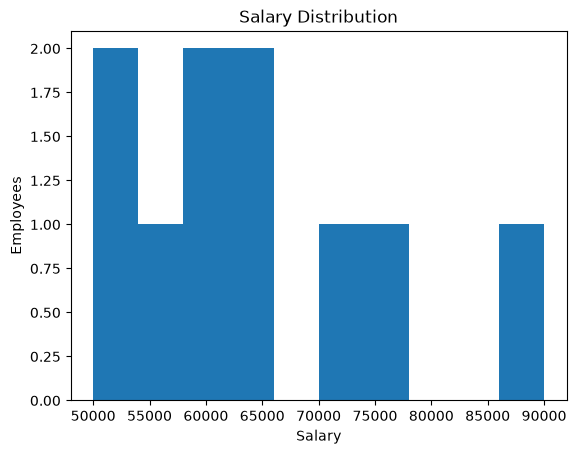

In [25]:
# Histogram
plt.hist(df["salary"])

plt.title("Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Employees")

plt.show()

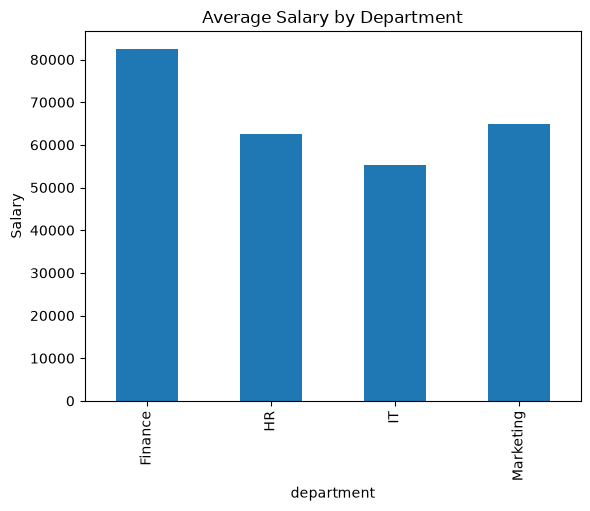

In [26]:
# Bar Graph
department_salary = df.groupby("department")["salary"].mean()

department_salary.plot(kind="bar")

plt.title("Average Salary by Department")

plt.ylabel("Salary")

plt.show()

# Task:
1. repeate with CSV File (read_csv) read_csv(employees.csv)

In [31]:
!python -m pip install openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import openpyxl
df = pd.read_json("employees.json")
print(df)


   id   name  age department   salary  experience
0   1   John   25         IT  50000.0           2
1   2  Alice   30         HR  60000.0           5
2   3    Bob   28         IT  55000.0           3
3   4  David   35    Finance  75000.0           8
4   5   Emma   27         HR      NaN           4


In [4]:
print(df.shape)

(10, 6)


In [17]:
print(df.info)

<bound method DataFrame.info of    id   name   age  department   salary   experience
0   1   John    25          IT  50000.0            2
1   2  Alice    30          HR  60000.0            5
2   3    Bob    28          IT  55000.0            3
3   4  David    35     Finance  75000.0            8
4   5   Emma    27          HR  58000.0            4
5   6  Frank    40     Finance  90000.0           12
6   7  Grace    26          IT  52000.0            2
7   8  Henry    31   Marketing  65000.0            6
8   9    Ivy    29          IT      NaN            4
9  10   Jack    33          HR  70000.0            7>


In [18]:
df.columns


Index(['id', ' name', ' age', ' department', ' salary', ' experience'], dtype='str')

In [19]:
print(df[' experience'].min())

2


In [20]:
df[' salary'].mean()

np.float64(63888.88888888889)

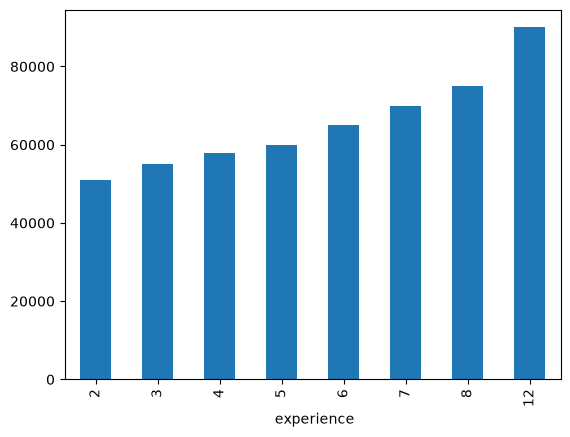

In [28]:
import matplotlib.pyplot as plt
experience_salary = df.groupby(' experience')[' salary'].mean()
experience_salary.plot(kind="bar")
plt.title=("average of experience and salary")
plt.ylabel=("salary")
plt.xlabel=("experience")
plt.show()